<a href="https://colab.research.google.com/github/jonabersaesime/ACTIVIDAD_5_IA/blob/Documentos_actividad_5/01_Logistic_Regression_AI4I_Interactivo_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación de Modelos de Inteligencia Artificial para Mantenimiento Predictivo

## Experimento 1: Regresión Logística utilizando el dataset AI4I 2020 Predictive Maintenance

---

## Maestría en Inteligencia Artificial

**Módulo 2 – Selección de Modelos Preentrenados y Prototipado Rápido**

---

### Alumno

**Jonathan Daniel Bernal Sánchez**

### Profesor

**Luis Ariel Vázquez Piña**

### Fecha

Julio 2026

---

# Descripción del proyecto

El presente proyecto tiene como finalidad desarrollar un prototipo de inteligencia artificial para la predicción de fallas en maquinaria industrial mediante el uso del dataset **AI4I 2020 Predictive Maintenance**. Para ello se implementan y comparan tres modelos de aprendizaje automático bajo las mismas condiciones de entrenamiento, validación y evaluación, con el propósito de identificar la alternativa que ofrezca el mejor equilibrio entre capacidad de predicción, eficiencia computacional y tiempo de respuesta.

Este cuaderno corresponde al primer experimento del proyecto, en el cual se implementa un modelo de **Regresión Logística**. Posteriormente, sus resultados serán comparados con los obtenidos mediante **Random Forest** y **XGBoost**, permitiendo realizar un análisis técnico sustentado en métricas objetivas como *Accuracy*, *Precision*, *Recall*, *F1-score* y latencia de inferencia.

---

# Objetivo

Implementar un modelo de Regresión Logística utilizando el dataset **AI4I 2020 Predictive Maintenance**, evaluando su desempeño mediante métricas estándar de clasificación y tiempo de inferencia para determinar su viabilidad dentro de un sistema de mantenimiento predictivo. Los resultados obtenidos servirán como línea base para comparar el comportamiento de otros modelos de inteligencia artificial implementados bajo las mismas condiciones experimentales.

---

# Contenido del Reporte Técnico

Este cuaderno se encuentra organizado en las siguientes secciones:

### 1. Introducción del proyecto
Descripción general del proyecto y del caso de uso.

### 2. Configuración del entorno
Configuración inicial de Google Colab y verificación del entorno de ejecución.

### 3. Verificación de GPU
Comprobación del acelerador por hardware disponible.

### 4. Instalación de dependencias
Instalación de todas las librerías necesarias para el desarrollo del proyecto.

### 5. Importación de librerías
Carga de librerías y configuración del entorno para garantizar la reproducibilidad.

### 6. Autenticación en Hugging Face Hub
Autenticación para acceder al ecosistema de Hugging Face.

### 7. Carga del dataset
Obtención del dataset AI4I 2020 Predictive Maintenance desde Hugging Face.

### 8. Exploración y descripción del dataset
Descripción de las variables y características principales del conjunto de datos.

### 9. Validación de calidad de datos
Revisión de valores faltantes, registros duplicados y distribución de la variable objetivo.

### 10. Selección de variables
Definición de las variables predictoras y de la variable objetivo.

### 11. División del conjunto de datos
Separación de los datos en conjuntos de entrenamiento y prueba.

### 12. Preprocesamiento
Transformación de variables categóricas y normalización de variables numéricas.

### 13. Construcción del pipeline
Creación del flujo de procesamiento y entrenamiento del modelo.

### 14. Entrenamiento del modelo
Entrenamiento del modelo de Regresión Logística.

### 15. Pipeline de inferencia
Predicción de nuevos registros mediante el modelo entrenado.

### 16. Medición de latencia
Evaluación del tiempo de entrenamiento, tiempo de inferencia y latencia promedio.

### 17. Evaluación del modelo
Cálculo de Accuracy, Precision, Recall, F1-score y ROC-AUC.

### 18. Matriz de confusión
Visualización e interpretación de los resultados obtenidos.

### 19. Visualización de resultados
Generación de gráficas para facilitar el análisis del desempeño del modelo.

### 20. Evaluación de umbrales
Comparación del comportamiento del modelo utilizando distintos umbrales de decisión.

### 21. Resumen del experimento
Concentrado de resultados y generación de archivos para su posterior comparación.

### 22. Conclusiones parciales
Interpretación de los resultados obtenidos y observaciones relevantes.

### 23. Riesgos y condiciones de ejecución
Limitaciones del experimento y documentación del entorno utilizado.

### 24. Simulador interactivo
Formulario para ingresar manualmente condiciones de operación y probar el modelo en tiempo real.

---

# Uso de la Inteligencia Artificial en esta actividad

Para el desarrollo de esta actividad se utilizó **ChatGPT** como herramienta de apoyo para planificar la estructura del proyecto, organizar el contenido técnico, documentar el proceso de desarrollo y generar un primer borrador del código necesario para la implementación del modelo.

Posteriormente, el código fue revisado, ajustado y validado manualmente durante su ejecución en **Google Colab**, verificando el correcto funcionamiento de cada etapa del proceso, así como la interpretación de las métricas obtenidas y la coherencia de los resultados con el objetivo del proyecto.

Asimismo, se utilizó el ecosistema de **Hugging Face** para la obtención del dataset empleado en el experimento y **Google Colab** como entorno de desarrollo para la implementación, entrenamiento y evaluación de los modelos de inteligencia artificial.

Las conclusiones, el análisis comparativo y la interpretación de los resultados corresponden al trabajo realizado por el autor a partir de la evidencia obtenida durante la ejecución de los experimentos.

---

# Autor del proyecto

**Alumno:** Jonathan Daniel Bernal Sánchez

**Profesor:** Luis Ariel Vázquez Piña

**Programa académico:** Maestría en Inteligencia Artificial

**Proyecto:** Comparación de modelos de inteligencia artificial para mantenimiento predictivo utilizando el dataset AI4I 2020 Predictive Maintenance.

**Versión del documento:** 1.0

## 1. Configuración del entorno de ejecución

En Google Colab se recomienda seleccionar:

`Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU T4`

La regresión logística de Scikit-learn se ejecuta principalmente en CPU. Sin embargo, se verifica la GPU para documentar que el entorno solicitado por la actividad se encuentra correctamente configurado y para mantener condiciones homogéneas entre los tres experimentos.

In [1]:
# Verificación de GPU disponible en Google Colab
import torch

if torch.cuda.is_available():
    print(" GPU detectada:")
    print(torch.cuda.get_device_name(0))
else:
    print(" No se detectó una GPU.")
    print("El notebook continuará utilizando CPU.")

 GPU detectada:
Tesla T4


## 2. Instalación de dependencias

Se instalan las librerías necesarias para cargar el dataset desde Hugging Face, entrenar el modelo, calcular métricas y generar visualizaciones.

In [2]:
!pip -q install datasets huggingface_hub scikit-learn pandas numpy matplotlib

## 3. Importación de librerías y reproducibilidad

Se establece una semilla aleatoria fija para que la división de datos sea reproducible en los tres cuadernos.

In [3]:
import os
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from huggingface_hub import notebook_login

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    roc_curve,
    roc_auc_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Entorno preparado correctamente.")

Entorno preparado correctamente.


## 4. Autenticación en Hugging Face Hub

La autenticación permite acceder al ecosistema Hugging Face y, posteriormente, publicar el modelo o los archivos del proyecto.

Al ejecutar la siguiente celda, Colab solicitará un token personal de Hugging Face. El token no debe escribirse directamente en el código ni compartirse en GitHub.

> Nota: el dataset utilizado es público, por lo que puede cargarse sin autenticación. La autenticación se incluye para cumplir con el flujo solicitado y permitir la publicación posterior del modelo.

In [4]:
# Ejecutar y pegar un token de Hugging Face cuando Colab lo solicite.
# Si únicamente se desea probar el notebook sin publicar archivos,
# esta celda puede omitirse porque el dataset es público.

notebook_login()

## 5. Carga del dataset desde Hugging Face

El dataset se carga directamente desde Hugging Face Datasets. Esto evita descargas manuales y facilita la reproducibilidad del experimento.

In [5]:
DATASET_ID = "TinchoARS/AI4I-2020-Predictive-Maintenance"

dataset = load_dataset(DATASET_ID)
dataset

README.md:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

ai4i2020.csv:   0%|          | 0.00/522k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
        num_rows: 10000
    })
})

In [6]:
# Conversión del split disponible a DataFrame de pandas
df = dataset["train"].to_pandas()

print(f"Registros: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
display(df.head())

Registros: 10,000
Columnas: 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 6. Descripción de las variables

Las principales variables del dataset son:

| Variable | Descripción |
|---|---|
| `UDI` | Identificador único del registro |
| `Product ID` | Identificador del producto |
| `Type` | Tipo o nivel de calidad del producto |
| `Air temperature [K]` | Temperatura del aire en Kelvin |
| `Process temperature [K]` | Temperatura del proceso en Kelvin |
| `Rotational speed [rpm]` | Velocidad de rotación |
| `Torque [Nm]` | Torque aplicado |
| `Tool wear [min]` | Desgaste acumulado de la herramienta |
| `Machine failure` | Variable objetivo: falla o no falla |
| `TWF`, `HDF`, `PWF`, `OSF`, `RNF` | Indicadores específicos del tipo de falla |

Para evitar fuga de información, los indicadores específicos de falla no se utilizarán como variables predictoras, ya que revelan directamente el resultado que se pretende predecir. También se eliminan los identificadores `UDI` y `Product ID`, porque no representan condiciones físicas de operación.

## 7. Revisión básica de calidad

El procesamiento será mínimo. Únicamente se verifican:

- valores faltantes;
- tipos de datos;
- distribución de la variable objetivo;
- duplicados.

No se realizará imputación ni limpieza compleja si el dataset ya se encuentra completo.

In [7]:
quality_summary = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "valores_nulos": df.isna().sum(),
    "valores_unicos": df.nunique()
})

display(quality_summary)
print(f"Filas duplicadas: {df.duplicated().sum()}")

,tipo_dato,valores_nulos,valores_unicos
UDI,int64,0,10000
Product ID,object,0,10000
Type,object,0,3
Air temperature [K],float64,0,93
Process temperature [K],float64,0,82
Rotational speed [rpm],int64,0,941
Torque [Nm],float64,0,577
Tool wear [min],int64,0,246
Machine failure,int64,0,2
TWF,int64,0,2


Filas duplicadas: 0


In [8]:
target_counts = df["Machine failure"].value_counts().sort_index()
target_percent = df["Machine failure"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Clase": ["Operación normal", "Falla"],
    "Registros": target_counts.values,
    "Porcentaje": target_percent.values
})

display(class_summary)

,Clase,Registros,Porcentaje
0,Operación normal,9661,96.61
1,Falla,339,3.39


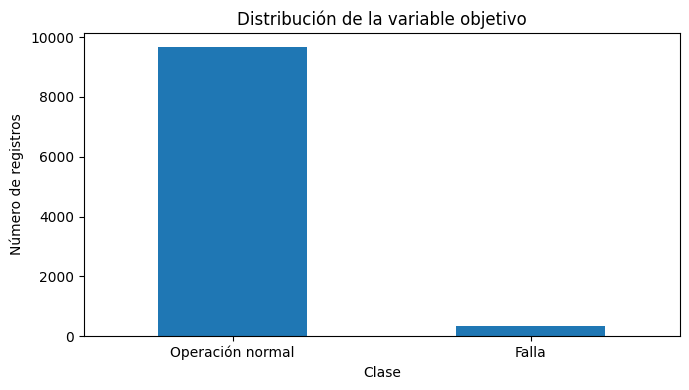

In [9]:
# Gráfica de distribución de clases
ax = class_summary.plot(
    x="Clase",
    y="Registros",
    kind="bar",
    legend=False,
    figsize=(7, 4)
)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observación sobre el desbalance

En mantenimiento predictivo es normal que existan más registros de operación correcta que registros de falla. Por esta razón, la exactitud (`accuracy`) no será suficiente para seleccionar el mejor modelo.

La comparación dará especial importancia a:

- **Recall:** proporción de fallas reales detectadas.
- **Precision:** proporción de alertas que realmente correspondieron a fallas.
- **F1-score:** equilibrio entre precision y recall.

## 8. Selección de variables y división de datos

Se utilizarán las variables físicas de operación y la categoría `Type`.

La división será:

- 80 % para entrenamiento.
- 20 % para prueba.
- Estratificación por la variable objetivo.
- Semilla aleatoria `42`.

Estas condiciones deberán mantenerse iguales en los tres cuadernos para realizar una comparación justa.

In [10]:
TARGET = "Machine failure"

DROP_COLUMNS = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
    TARGET
]

X = df.drop(columns=DROP_COLUMNS)
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Dimensiones:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

display(X_train.head())

Dimensiones:
X_train: (8000, 6)
X_test:  (2000, 6)
y_train: (8000,)
y_test:  (2000,)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
4058,M,302.0,310.9,1456,47.2,54
1221,M,297.0,308.3,1399,46.4,132
6895,M,301.0,311.6,1357,45.6,137
9863,L,298.9,309.8,1411,56.3,84
8711,L,297.1,308.5,1733,28.7,50


## 9. Preprocesamiento mínimo

La única variable categórica es `Type`, que se transforma mediante **One-Hot Encoding**.

Las variables numéricas se estandarizan porque la regresión logística puede verse afectada por las diferencias de escala entre temperatura, velocidad, torque y desgaste.

Todo el procesamiento se integra dentro de un único `Pipeline`, lo cual evita inconsistencias entre entrenamiento e inferencia.

In [11]:
categorical_features = ["Type"]
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)

model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type']),
                                                 ('numeric', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

### Decisión de ajuste mínimo

Se utiliza `class_weight="balanced"` para compensar el desbalance de clases sin modificar ni generar registros artificiales. Este ajuste asigna mayor importancia a los ejemplos de falla durante el entrenamiento.

No se aplicará sobremuestreo, submuestreo ni generación sintética de datos, con el propósito de mantener el dataset original y simplificar la reproducibilidad.

## 10. Entrenamiento del modelo

Se mide el tiempo total requerido para ajustar el pipeline.

In [12]:
start_train = time.perf_counter()

model_pipeline.fit(X_train, y_train)

training_time = time.perf_counter() - start_train

print(f"Tiempo de entrenamiento: {training_time:.4f} segundos")

Tiempo de entrenamiento: 0.0988 segundos


## 11. Pipeline de inferencia

El pipeline recibe directamente registros con la estructura original del dataset, aplica las transformaciones necesarias y genera una predicción:

- `0`: operación normal.
- `1`: falla probable.

In [13]:
# Ejemplo de inferencia con cinco registros
sample_records = X_test.head(5).copy()
sample_predictions = model_pipeline.predict(sample_records)
sample_probabilities = model_pipeline.predict_proba(sample_records)[:, 1]

inference_example = sample_records.copy()
inference_example["Predicción"] = sample_predictions
inference_example["Probabilidad de falla"] = sample_probabilities

display(inference_example)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Predicción,Probabilidad de falla
2997,L,300.5,309.8,1345,62.7,153,1,0.971350
4871,L,303.7,312.4,1513,40.1,135,1,0.537908
3858,L,302.5,311.4,1559,37.6,209,1,0.680196
951,H,295.6,306.3,1509,35.8,60,0,0.010477
6463,H,300.5,310.0,1358,60.4,102,1,0.854788


## 12. Predicción y medición de latencia

La latencia se mide sobre el conjunto de prueba completo y se reporta como:

- tiempo total;
- tiempo promedio por registro;
- registros procesados por segundo.

In [14]:
start_inference = time.perf_counter()

y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

total_inference_time = time.perf_counter() - start_inference
latency_per_record_ms = (total_inference_time / len(X_test)) * 1000
records_per_second = len(X_test) / total_inference_time

print(f"Tiempo total de inferencia: {total_inference_time:.6f} s")
print(f"Latencia promedio: {latency_per_record_ms:.6f} ms/registro")
print(f"Rendimiento: {records_per_second:,.2f} registros/s")

Tiempo total de inferencia: 0.027768 s
Latencia promedio: 0.013884 ms/registro
Rendimiento: 72,026.44 registros/s


## 13. Cálculo de métricas

Las métricas se calculan considerando la clase positiva `1`, correspondiente a falla de máquina.

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Tiempo de entrenamiento (s)",
        "Tiempo de inferencia total (s)",
        "Latencia promedio (ms/registro)"
    ],
    "Resultado": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        training_time,
        total_inference_time,
        latency_per_record_ms
    ]
})

display(metrics_df)

,Métrica,Resultado
0,Accuracy,0.824500
1,Precision,0.141772
2,Recall,0.823529
3,F1-score,0.241901
4,ROC-AUC,0.906954
5,Tiempo de entrenamiento (s),0.098795
6,Tiempo de inferencia total (s),0.027768
7,Latencia promedio (ms/registro),0.013884


In [16]:
print("Reporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Operación normal", "Falla"],
        digits=4,
        zero_division=0
    )
)

Reporte de clasificación:
                  precision    recall  f1-score   support

Operación normal     0.9925    0.8245    0.9008      1932
           Falla     0.1418    0.8235    0.2419        68

        accuracy                         0.8245      2000
       macro avg     0.5671    0.8240    0.5713      2000
    weighted avg     0.9636    0.8245    0.8784      2000



## 14. Matriz de confusión

La matriz de confusión permite identificar:

- verdaderos negativos: operaciones normales clasificadas correctamente;
- falsos positivos: alertas de falla innecesarias;
- falsos negativos: fallas no detectadas;
- verdaderos positivos: fallas detectadas correctamente.

En mantenimiento predictivo, los falsos negativos representan uno de los principales riesgos porque corresponden a fallas que el modelo no anticipó.

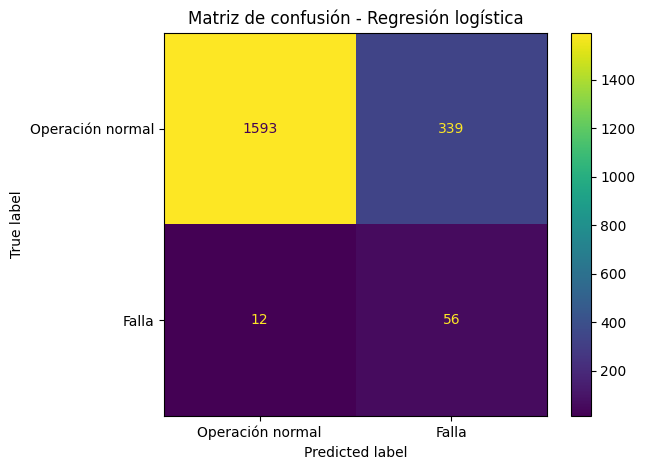

In [17]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Operación normal", "Falla"]
)
disp.plot(values_format="d")
plt.title("Matriz de confusión - Regresión logística")
plt.tight_layout()
plt.show()

## 15. Gráfica de métricas principales

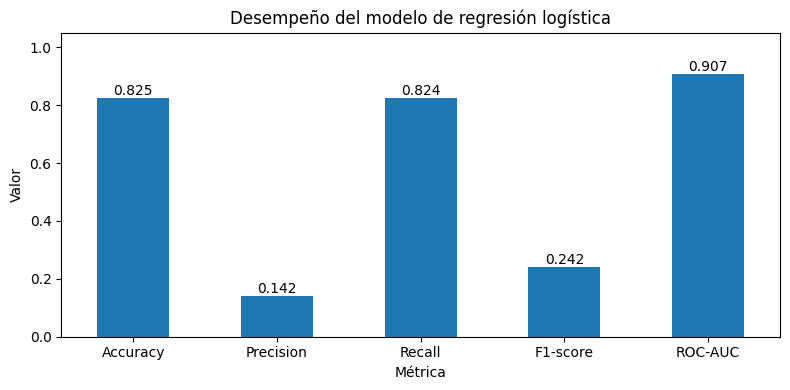

In [18]:
main_metrics = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Valor": [accuracy, precision, recall, f1, roc_auc]
})

ax = main_metrics.plot(
    x="Métrica",
    y="Valor",
    kind="bar",
    legend=False,
    figsize=(8, 4)
)
ax.set_title("Desempeño del modelo de regresión logística")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.show()

## 16. Curva ROC

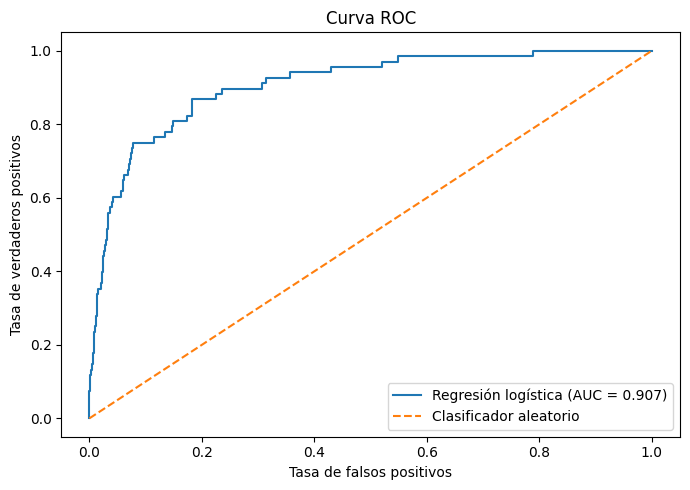

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Regresión logística (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.title("Curva ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Curva Precision-Recall

Esta gráfica es especialmente útil cuando la clase de falla está menos representada.

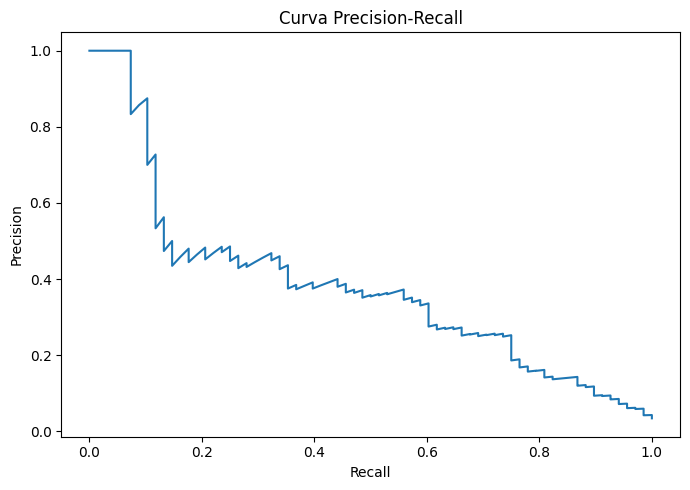

In [20]:
pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(pr_recall, pr_precision)
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

## 18. Análisis de probabilidades predichas

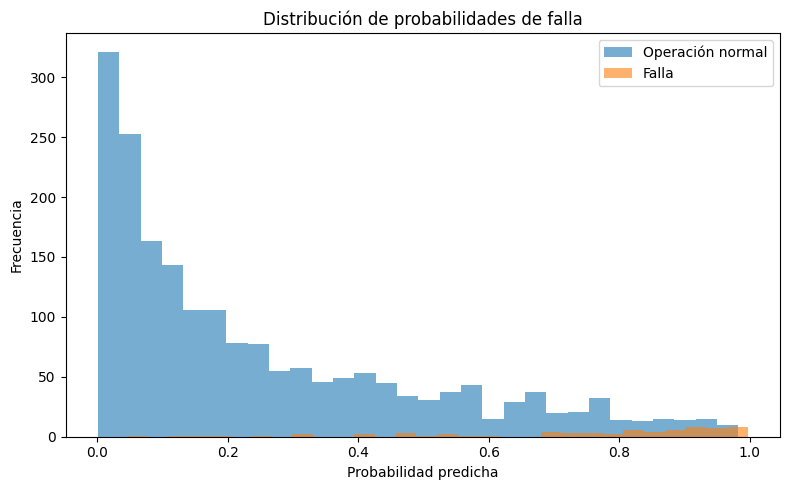

In [21]:
probability_df = pd.DataFrame({
    "Probabilidad de falla": y_prob,
    "Clase real": y_test.reset_index(drop=True)
})

plt.figure(figsize=(8, 5))

for class_value, class_name in [(0, "Operación normal"), (1, "Falla")]:
    subset = probability_df[
        probability_df["Clase real"] == class_value
    ]["Probabilidad de falla"]
    plt.hist(
        subset,
        bins=30,
        alpha=0.6,
        label=class_name
    )

plt.title("Distribución de probabilidades de falla")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

## 19. Evaluación de umbrales

El umbral predeterminado es `0.50`. Sin embargo, en mantenimiento predictivo puede ser conveniente reducirlo para aumentar el recall y detectar una mayor proporción de fallas, aun cuando esto incremente las falsas alarmas.

Esta tabla permite observar el trade-off entre precision y recall.

In [22]:
threshold_results = []

for threshold in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Umbral": threshold,
        "Accuracy": accuracy_score(y_test, threshold_pred),
        "Precision": precision_score(y_test, threshold_pred, zero_division=0),
        "Recall": recall_score(y_test, threshold_pred, zero_division=0),
        "F1-score": f1_score(y_test, threshold_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,Umbral,Accuracy,Precision,Recall,F1-score
0,0.2,0.5825,0.072464,0.955882,0.134715
1,0.3,0.6865,0.091971,0.926471,0.167331
2,0.4,0.7620,0.115094,0.897059,0.204013
3,0.5,0.8245,0.141772,0.823529,0.241901
4,0.6,0.8760,0.183099,0.764706,0.295455
5,0.7,0.9160,0.250000,0.735294,0.373134


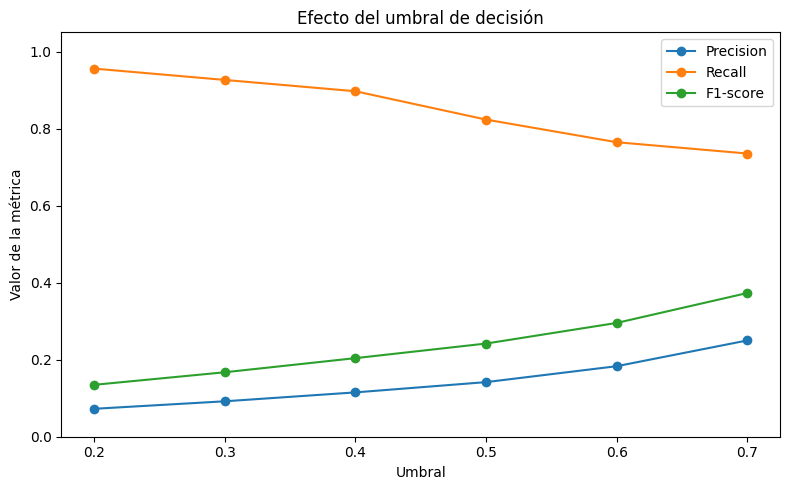

In [23]:
plt.figure(figsize=(8, 5))

for metric in ["Precision", "Recall", "F1-score"]:
    plt.plot(
        threshold_df["Umbral"],
        threshold_df[metric],
        marker="o",
        label=metric
    )

plt.title("Efecto del umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 20. Resumen del experimento

Se genera un registro estructurado para conservar los resultados y utilizarlos posteriormente en la tabla comparativa de los tres modelos.

In [24]:
experiment_results = {
    "model": "Logistic Regression",
    "dataset": DATASET_ID,
    "random_state": RANDOM_STATE,
    "train_records": int(len(X_train)),
    "test_records": int(len(X_test)),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),
    "training_time_seconds": float(training_time),
    "total_inference_time_seconds": float(total_inference_time),
    "latency_ms_per_record": float(latency_per_record_ms),
    "records_per_second": float(records_per_second)
}

print(json.dumps(experiment_results, indent=2))

{
  "model": "Logistic Regression",
  "dataset": "TinchoARS/AI4I-2020-Predictive-Maintenance",
  "random_state": 42,
  "train_records": 8000,
  "test_records": 2000,
  "accuracy": 0.8245,
  "precision": 0.14177215189873418,
  "recall": 0.8235294117647058,
  "f1_score": 0.24190064794816415,
  "roc_auc": 0.9069540859822189,
  "training_time_seconds": 0.09879483499997832,
  "total_inference_time_seconds": 0.027767579999988357,
  "latency_ms_per_record": 0.013883789999994178,
  "records_per_second": 72026.44234754483
}


In [25]:
# Guardar los resultados para el repositorio de GitHub
with open("logistic_regression_results.json", "w", encoding="utf-8") as file:
    json.dump(experiment_results, file, indent=2, ensure_ascii=False)

metrics_df.to_csv("logistic_regression_metrics.csv", index=False)
threshold_df.to_csv("logistic_regression_thresholds.csv", index=False)

print("Archivos generados:")
print("- logistic_regression_results.json")
print("- logistic_regression_metrics.csv")
print("- logistic_regression_thresholds.csv")

Archivos generados:
- logistic_regression_results.json
- logistic_regression_metrics.csv
- logistic_regression_thresholds.csv


## 21. Conclusiones parciales

Después de ejecutar todas las celdas, esta sección deberá completarse utilizando los valores reales obtenidos.

### Interpretación sugerida

1. **Desempeño general:** indicar el valor de accuracy, sin utilizarlo como único criterio debido al desbalance de clases.
2. **Detección de fallas:** analizar el recall y la cantidad de falsos negativos.
3. **Confiabilidad de las alertas:** analizar la precision y los falsos positivos.
4. **Equilibrio:** revisar el F1-score.
5. **Eficiencia:** documentar el tiempo de entrenamiento y la latencia promedio.
6. **Umbral:** evaluar si el valor predeterminado de 0.50 es adecuado o si conviene reducirlo para incrementar la detección de fallas.
7. **Comparación futura:** conservar los resultados para compararlos con Random Forest y XGBoost.

### Conclusión preliminar del modelo

La regresión logística funciona como línea base debido a su baja complejidad, rapidez e interpretabilidad. Su selección final dependerá de si alcanza el recall y el F1-score definidos para el proyecto y de cómo se compare con los otros dos modelos.

No debe recomendarse un modelo definitivo hasta ejecutar los tres experimentos bajo las mismas condiciones.

## 22. Riesgos y limitaciones

- El dataset es sintético y puede no representar todas las variaciones de una planta real.
- Existe desbalance entre operación normal y falla.
- Los indicadores específicos de falla fueron excluidos para evitar fuga de información.
- Un falso negativo podría ocasionar que una falla real no sea detectada.
- Un falso positivo podría generar inspecciones o paros innecesarios.
- Los resultados dependen del conjunto de datos y no deben trasladarse directamente a una máquina real sin validación adicional.

## 23. Condiciones de ejecución

Al finalizar el experimento se recomienda registrar:

- Entorno: Google Colab.
- Acelerador configurado: GPU T4.
- Modelo: Regresión logística de Scikit-learn.
- Semilla: 42.
- División: 80 % entrenamiento y 20 % prueba.
- Estratificación: sí.
- Ajuste de clases: `class_weight="balanced"`.
- Dataset: `TinchoARS/AI4I-2020-Predictive-Maintenance`.
- Librerías y versiones: consultar la siguiente celda.

In [26]:
import sklearn
import datasets
import huggingface_hub
import matplotlib

versions = {
    "Python": os.sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "datasets": datasets.__version__,
    "huggingface_hub": huggingface_hub.__version__,
    "matplotlib": matplotlib.__version__
}

pd.DataFrame(
    versions.items(),
    columns=["Componente", "Versión"]
)

,Componente,Versión
0,Python,3.12.13
1,pandas,2.2.2
2,numpy,2.0.2
3,scikit-learn,1.6.1
4,datasets,4.0.0
5,huggingface_hub,1.20.1
6,matplotlib,3.10.0


## 24. Prueba interactiva del modelo

Esta sección permite que el usuario ingrese manualmente las condiciones de operación de una máquina y pruebe el modelo entrenado.

El formulario solicita los mismos campos utilizados durante el entrenamiento:

- tipo de producto;
- temperatura del aire;
- temperatura del proceso;
- velocidad de rotación;
- torque;
- desgaste de herramienta.

Al seleccionar **Probar modelo**, el pipeline aplica automáticamente el mismo preprocesamiento utilizado durante el entrenamiento y muestra la clasificación estimada, la probabilidad de falla y una interpretación sencilla.

> Los valores predeterminados se calculan con la mediana del dataset y pueden modificarse libremente.

In [27]:
!pip -q install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.6 MB/s eta 0:00:00


In [28]:
import ipywidgets as widgets
from IPython.display import display, clear_output

reference_ranges = pd.DataFrame({
    "Variable": [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ],
    "Mínimo": [
        df["Air temperature [K]"].min(),
        df["Process temperature [K]"].min(),
        df["Rotational speed [rpm]"].min(),
        df["Torque [Nm]"].min(),
        df["Tool wear [min]"].min()
    ],
    "Máximo": [
        df["Air temperature [K]"].max(),
        df["Process temperature [K]"].max(),
        df["Rotational speed [rpm]"].max(),
        df["Torque [Nm]"].max(),
        df["Tool wear [min]"].max()
    ]
})

display(reference_ranges)

,Variable,Mínimo,Máximo
0,Air temperature [K],295.3,304.5
1,Process temperature [K],305.7,313.8
2,Rotational speed [rpm],1168.0,2886.0
3,Torque [Nm],3.8,76.6
4,Tool wear [min],0.0,253.0


In [29]:
type_widget = widgets.Dropdown(
    options=["L", "M", "H"],
    value="M",
    description="Tipo:",
    style={"description_width": "180px"}
)

air_temp_widget = widgets.FloatSlider(
    value=float(df["Air temperature [K]"].median()),
    min=float(df["Air temperature [K]"].min()),
    max=float(df["Air temperature [K]"].max()),
    step=0.1,
    description="Temp. aire [K]:",
    continuous_update=False,
    style={"description_width": "180px"},
    layout=widgets.Layout(width="700px")
)

process_temp_widget = widgets.FloatSlider(
    value=float(df["Process temperature [K]"].median()),
    min=float(df["Process temperature [K]"].min()),
    max=float(df["Process temperature [K]"].max()),
    step=0.1,
    description="Temp. proceso [K]:",
    continuous_update=False,
    style={"description_width": "180px"},
    layout=widgets.Layout(width="700px")
)

rotational_speed_widget = widgets.IntSlider(
    value=int(df["Rotational speed [rpm]"].median()),
    min=int(df["Rotational speed [rpm]"].min()),
    max=int(df["Rotational speed [rpm]"].max()),
    step=1,
    description="Velocidad [rpm]:",
    continuous_update=False,
    style={"description_width": "180px"},
    layout=widgets.Layout(width="700px")
)

torque_widget = widgets.FloatSlider(
    value=float(df["Torque [Nm]"].median()),
    min=float(df["Torque [Nm]"].min()),
    max=float(df["Torque [Nm]"].max()),
    step=0.1,
    description="Torque [Nm]:",
    continuous_update=False,
    style={"description_width": "180px"},
    layout=widgets.Layout(width="700px")
)

tool_wear_widget = widgets.IntSlider(
    value=int(df["Tool wear [min]"].median()),
    min=int(df["Tool wear [min]"].min()),
    max=int(df["Tool wear [min]"].max()),
    step=1,
    description="Desgaste [min]:",
    continuous_update=False,
    style={"description_width": "180px"},
    layout=widgets.Layout(width="700px")
)

predict_button = widgets.Button(
    description="Probar modelo",
    button_style="primary",
    icon="check"
)

reset_button = widgets.Button(
    description="Restablecer",
    icon="refresh"
)

output_widget = widgets.Output()

In [30]:
def predict_machine_failure(_):
    with output_widget:
        clear_output()

        input_data = pd.DataFrame([{
            "Type": type_widget.value,
            "Air temperature [K]": air_temp_widget.value,
            "Process temperature [K]": process_temp_widget.value,
            "Rotational speed [rpm]": rotational_speed_widget.value,
            "Torque [Nm]": torque_widget.value,
            "Tool wear [min]": tool_wear_widget.value
        }])

        prediction = int(model_pipeline.predict(input_data)[0])
        failure_probability = float(
            model_pipeline.predict_proba(input_data)[0, 1]
        )

        result_table = input_data.copy()
        result_table["Predicción"] = (
            "Falla probable" if prediction == 1 else "Operación normal"
        )
        result_table["Probabilidad de falla"] = failure_probability

        display(result_table)
        print(f"Probabilidad estimada de falla: {failure_probability:.2%}")

        if prediction == 1:
            print(
                "Resultado: el modelo identifica una posible condición de falla. "
                "Se recomienda realizar una inspección preventiva."
            )
        else:
            print(
                "Resultado: el modelo clasifica las condiciones ingresadas como operación normal."
            )

        print(
            "\nNota: este resultado corresponde a un prototipo académico y no sustituye "
            "la evaluación de personal técnico."
        )


def reset_form(_):
    type_widget.value = "M"
    air_temp_widget.value = float(df["Air temperature [K]"].median())
    process_temp_widget.value = float(df["Process temperature [K]"].median())
    rotational_speed_widget.value = int(df["Rotational speed [rpm]"].median())
    torque_widget.value = float(df["Torque [Nm]"].median())
    tool_wear_widget.value = int(df["Tool wear [min]"].median())

    with output_widget:
        clear_output()
        print("Formulario restablecido.")


predict_button.on_click(predict_machine_failure)
reset_button.on_click(reset_form)

In [31]:
display(
    widgets.VBox([
        widgets.HTML("<h3>Simulador de predicción de falla</h3>"),
        type_widget,
        air_temp_widget,
        process_temp_widget,
        rotational_speed_widget,
        torque_widget,
        tool_wear_widget,
        widgets.HBox([predict_button, reset_button]),
        output_widget
    ])
)

### Interpretación

El simulador usa exactamente el mismo pipeline entrenado en este notebook. Por ello, las transformaciones y la lógica de clasificación son consistentes con los resultados de evaluación.

La probabilidad mostrada debe interpretarse como una estimación del modelo y no como una certeza absoluta.